In [12]:
import sys
from pathlib import Path

# Ajustar el path del proyecto para importar el módulo desde src/
project_root = Path.cwd()
while project_root != project_root.parent and not (project_root / "src").exists():
    project_root = project_root.parent

if not (project_root / "src").exists():
    raise FileNotFoundError("No se encontró la carpeta 'src' en el árbol de directorios.")

# Importante: insertar la raíz del proyecto, no la carpeta src.
sys.path.insert(0, str(project_root.resolve()))
print("project_root:", project_root)
print("sys.path[0]:", sys.path[0])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.vector_director import run_cluster_analysis_from_dataframe
import importlib
import src.vector_director as vd
importlib.reload(vd)
from src.vector_director import run_cluster_analysis_from_dataframe


project_root: c:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project
sys.path[0]: C:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project


In [13]:
def unit_vector_to_galactic_lb(vector: np.ndarray) -> dict:
    """
    Convierte un vector cartesiano galáctico 3D a coordenadas l, b.

    Parameters
    ----------
    vector : np.ndarray
        Vector 3D en coordenadas galácticas cartesianas.

    Returns
    -------
    dict
        Diccionario con l_deg, b_deg, l_rad, b_rad.
    """

    vector = np.asarray(vector, dtype=float)
    norm = np.linalg.norm(vector)

    if norm == 0.0:
        raise ValueError("Input vector has zero norm.")

    unit_vector = vector / norm

    x_coord, y_coord, z_coord = unit_vector

    l_rad = np.arctan2(y_coord, x_coord) % (2.0 * np.pi)
    b_rad = np.arcsin(np.clip(z_coord, -1.0, 1.0))

    return {
        "l_deg": np.degrees(l_rad),
        "b_deg": np.degrees(b_rad),
        "l_rad": l_rad,
        "b_rad": b_rad,
    }


def extract_cross_product_apex_candidates(
    analysis_result: dict,
    use_refined: bool = True,
    weight_col: str | None = None,
    pole_x_col: str = "pole_x_unit",
    pole_y_col: str = "pole_y_unit",
    pole_z_col: str = "pole_z_unit",
    min_cross_norm: float = 1e-12,
) -> pd.DataFrame:
    """
    Extrae todos los candidatos a ápex generados por productos cruzados
    entre pares de polos.

    Parameters
    ----------
    analysis_result : dict
        Resultado devuelto por `process_single_cluster`.

    use_refined : bool, optional
        Si True, usa el DataFrame refinado si existe.

    weight_col : str or None, optional
        Columna de pesos. Por ejemplo: "probabilidad".

    pole_x_col, pole_y_col, pole_z_col : str
        Columnas con los polos unitarios.

    min_cross_norm : float
        Norma mínima aceptada para el producto cruz entre dos polos.

    Returns
    -------
    pd.DataFrame
        Tabla con candidatos:

        - apex_l_deg
        - apex_b_deg
        - candidate_weight
        - cross_norm
        - i
        - j
    """

    if use_refined and "df_refined" in analysis_result:
        df = analysis_result["df_refined"].copy()
        apex_result = analysis_result.get("apex_refined")
    else:
        df = analysis_result["df_initial"].copy()
        apex_result = analysis_result.get("apex_initial")

    if apex_result is None or "error" in apex_result:
        apex_result = analysis_result["apex_result"]

    reference_apex_vector = np.asarray(
        apex_result["apex_vector"],
        dtype=float,
    )
    reference_apex_vector = (
        reference_apex_vector / np.linalg.norm(reference_apex_vector)
    )

    required_cols = [pole_x_col, pole_y_col, pole_z_col]

    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column: {col}")

    poles = df[[pole_x_col, pole_y_col, pole_z_col]].to_numpy(dtype=float)

    valid = np.isfinite(poles).all(axis=1)
    pole_norms = np.linalg.norm(poles, axis=1)
    valid &= pole_norms > 0.0

    df_valid = df.loc[valid].copy()
    poles = poles[valid] / pole_norms[valid, None]

    if weight_col is not None and weight_col in df_valid.columns:
        weights = df_valid[weight_col].to_numpy(dtype=float)
        weights = np.where(np.isfinite(weights) & (weights > 0.0), weights, 1.0)
    else:
        weights = np.ones(len(df_valid), dtype=float)

    candidates = []

    n_poles = len(poles)

    for i in range(n_poles):
        for j in range(i + 1, n_poles):
            cross_vector = np.cross(poles[i], poles[j])
            cross_norm = np.linalg.norm(cross_vector)

            if cross_norm <= min_cross_norm:
                continue

            candidate_vector = cross_vector / cross_norm

            # Orientar hacia el mismo hemisferio que el ápex estimado.
            if np.dot(candidate_vector, reference_apex_vector) < 0.0:
                candidate_vector = -candidate_vector

            coords = unit_vector_to_galactic_lb(candidate_vector)

            candidate_weight = weights[i] * weights[j] * cross_norm

            candidates.append(
                {
                    "i": i,
                    "j": j,
                    "apex_l_deg": coords["l_deg"],
                    "apex_b_deg": coords["b_deg"],
                    "candidate_weight": candidate_weight,
                    "cross_norm": cross_norm,
                }
            )

    if len(candidates) == 0:
        raise ValueError("No valid cross-product apex candidates found.")

    return pd.DataFrame(candidates)


def get_lambda_values_from_result(
    analysis_result: dict,
    use_refined: bool = True,
) -> np.ndarray:
    """
    Extrae los valores de lambda_deg desde el resultado del análisis.
    """

    if use_refined and "df_refined" in analysis_result:
        df = analysis_result["df_refined"]
    else:
        df = analysis_result["df_initial"]

    if "lambda_deg_refined" in df.columns:
        lambda_values = df["lambda_deg_refined"].to_numpy(dtype=float)
    elif "lambda_deg_initial" in df.columns:
        lambda_values = df["lambda_deg_initial"].to_numpy(dtype=float)
    elif "lambda_deg" in df.columns:
        lambda_values = df["lambda_deg"].to_numpy(dtype=float)
    else:
        raise ValueError(
            "No lambda column found. Expected lambda_deg, "
            "lambda_deg_initial or lambda_deg_refined."
        )

    return lambda_values[np.isfinite(lambda_values)]


import numpy as np
import matplotlib.pyplot as plt


def wrap_angle_deg(angle_deg: np.ndarray) -> np.ndarray:
    """
    Lleva ángulos en grados al intervalo [-180, 180).
    """

    return (angle_deg + 180.0) % 360.0 - 180.0


def weighted_quantile(
    values: np.ndarray,
    quantiles: list[float],
    weights: np.ndarray | None = None,
) -> np.ndarray:
    """
    Calcula cuantiles ponderados.

    Parameters
    ----------
    values : np.ndarray
        Valores de entrada.

    quantiles : list[float]
        Cuantiles entre 0 y 1.

    weights : np.ndarray or None
        Pesos. Si es None, usa cuantiles no ponderados.

    Returns
    -------
    np.ndarray
        Cuantiles solicitados.
    """

    values = np.asarray(values, dtype=float)
    quantiles = np.asarray(quantiles, dtype=float)

    valid = np.isfinite(values)

    if weights is None:
        return np.quantile(values[valid], quantiles)

    weights = np.asarray(weights, dtype=float)
    valid &= np.isfinite(weights)
    valid &= weights > 0.0

    values = values[valid]
    weights = weights[valid]

    if len(values) == 0:
        return np.full_like(quantiles, np.nan, dtype=float)

    sorter = np.argsort(values)
    values = values[sorter]
    weights = weights[sorter]

    cumulative_weights = np.cumsum(weights)
    cumulative_weights /= cumulative_weights[-1]

    return np.interp(quantiles, cumulative_weights, values)


def weighted_mean_and_std(
    values: np.ndarray,
    weights: np.ndarray | None = None,
) -> tuple[float, float]:
    """
    Media y desviación estándar ponderadas.
    """

    values = np.asarray(values, dtype=float)
    valid = np.isfinite(values)

    if weights is None:
        clean_values = values[valid]
        return float(np.mean(clean_values)), float(np.std(clean_values))

    weights = np.asarray(weights, dtype=float)
    valid &= np.isfinite(weights)
    valid &= weights > 0.0

    clean_values = values[valid]
    clean_weights = weights[valid]

    mean = np.average(clean_values, weights=clean_weights)
    variance = np.average(
        (clean_values - mean) ** 2,
        weights=clean_weights,
    )

    return float(mean), float(np.sqrt(variance))


def weighted_circular_mean_and_std_deg(
    angles_deg: np.ndarray,
    weights: np.ndarray | None = None,
) -> tuple[float, float]:
    """
    Media circular y desviación circular para ángulos en grados.

    Útil para longitud galáctica l, porque l = 359° y l = 1°
    están cerca angularmente.
    """

    angles_deg = np.asarray(angles_deg, dtype=float)
    valid = np.isfinite(angles_deg)

    if weights is None:
        clean_weights = np.ones(valid.sum(), dtype=float)
    else:
        weights = np.asarray(weights, dtype=float)
        valid &= np.isfinite(weights)
        valid &= weights > 0.0
        clean_weights = weights[valid]

    clean_angles_rad = np.deg2rad(angles_deg[valid])

    sin_mean = np.average(np.sin(clean_angles_rad), weights=clean_weights)
    cos_mean = np.average(np.cos(clean_angles_rad), weights=clean_weights)

    mean_rad = np.arctan2(sin_mean, cos_mean) % (2.0 * np.pi)

    resultant_length = np.sqrt(sin_mean**2 + cos_mean**2)
    resultant_length = np.clip(resultant_length, 1e-15, 1.0)

    std_rad = np.sqrt(-2.0 * np.log(resultant_length))

    return float(np.rad2deg(mean_rad)), float(np.rad2deg(std_rad))


def galactic_lb_to_unit_vectors(
    l_deg: np.ndarray,
    b_deg: np.ndarray,
) -> np.ndarray:
    """
    Convierte coordenadas galácticas l, b a vectores cartesianos unitarios.
    """

    l_rad = np.deg2rad(l_deg)
    b_rad = np.deg2rad(b_deg)

    x_coord = np.cos(l_rad) * np.cos(b_rad)
    y_coord = np.sin(l_rad) * np.cos(b_rad)
    z_coord = np.sin(b_rad)

    return np.column_stack((x_coord, y_coord, z_coord))


def angular_separation_deg(
    vectors_a: np.ndarray,
    vector_b: np.ndarray,
) -> np.ndarray:
    """
    Calcula separación angular entre muchos vectores y un vector de referencia.
    """

    vectors_a = np.asarray(vectors_a, dtype=float)
    vector_b = np.asarray(vector_b, dtype=float)

    vectors_a = vectors_a / np.linalg.norm(vectors_a, axis=1)[:, None]
    vector_b = vector_b / np.linalg.norm(vector_b)

    cos_angle = np.clip(vectors_a @ vector_b, -1.0, 1.0)

    return np.rad2deg(np.arccos(cos_angle))


def add_stats_box(
    ax: plt.Axes,
    text: str,
    loc: str = "upper right",
) -> None:
    """
    Agrega una caja de texto con estadísticas dentro de un eje.
    """

    positions = {
        "upper right": (0.97, 0.97, "right", "top"),
        "upper left": (0.03, 0.97, "left", "top"),
        "lower right": (0.97, 0.03, "right", "bottom"),
        "lower left": (0.03, 0.03, "left", "bottom"),
    }

    x_pos, y_pos, ha_text, va_text = positions[loc]

    ax.text(
        x_pos,
        y_pos,
        text,
        transform=ax.transAxes,
        ha=ha_text,
        va=va_text,
        fontsize=9,
        bbox={
            "boxstyle": "round",
            "facecolor": "white",
            "alpha": 0.82,
            "edgecolor": "gray",
        },
    )


def plot_apex_candidate_diagnostics(
    analysis_result: dict,
    true_apex_l_deg: float | None = None,
    true_apex_b_deg: float | None = None,
    use_refined: bool = True,
    weight_col: str | None = None,
    bins_l: int = 40,
    bins_b: int = 40,
    bins_lambda: int = 40,
    bins_residual: int = 40,
    figsize: tuple[float, float] = (14.0, 9.0),
) -> tuple[plt.Figure, np.ndarray, object]:
    """
    Grafica diagnósticos de candidatos a ápex por producto cruz.

    Incluye:

    1. Histograma ponderado de l de candidatos.
    2. Histograma ponderado de b de candidatos.
    3. Histograma de lambda de las estrellas.
    4. Histograma del residuo angular de candidatos respecto al ápex.

    Parameters
    ----------
    analysis_result : dict
        Salida de `process_single_cluster`.

    true_apex_l_deg : float or None
        Longitud galáctica verdadera del ápex simulado, en grados.

    true_apex_b_deg : float or None
        Latitud galáctica verdadera del ápex simulado, en grados.

    use_refined : bool
        Si True, usa el resultado refinado.

    weight_col : str or None
        Columna de pesos para los candidatos.

    Returns
    -------
    tuple
        fig, axes, candidates_df.
    """

    candidates_df = extract_cross_product_apex_candidates(
        analysis_result=analysis_result,
        use_refined=use_refined,
        weight_col=weight_col,
    )

    lambda_values = get_lambda_values_from_result(
        analysis_result=analysis_result,
        use_refined=use_refined,
    )

    if use_refined and "apex_refined" in analysis_result:
        apex_result = analysis_result["apex_refined"]
    else:
        apex_result = analysis_result["apex_initial"]

    if apex_result is None or "error" in apex_result:
        apex_result = analysis_result["apex_result"]

    estimated_l = float(apex_result["apex_l_deg"])
    estimated_b = float(apex_result["apex_b_deg"])

    weights = candidates_df["candidate_weight"].to_numpy(dtype=float)

    candidate_vectors = galactic_lb_to_unit_vectors(
        candidates_df["apex_l_deg"].to_numpy(dtype=float),
        candidates_df["apex_b_deg"].to_numpy(dtype=float),
    )

    estimated_vector = np.asarray(apex_result["apex_vector"], dtype=float)

    residual_to_estimated = angular_separation_deg(
        candidate_vectors,
        estimated_vector,
    )

    candidates_df["residual_to_estimated_deg"] = residual_to_estimated

    if true_apex_l_deg is not None and true_apex_b_deg is not None:
        true_vector = galactic_lb_to_unit_vectors(
            np.array([true_apex_l_deg]),
            np.array([true_apex_b_deg]),
        )[0]

        residual_to_true = angular_separation_deg(
            candidate_vectors,
            true_vector,
        )

        candidates_df["residual_to_true_deg"] = residual_to_true
        residual_values = residual_to_true
        residual_label = "Residuo angular respecto al ápex verdadero [deg]"
    else:
        residual_values = residual_to_estimated
        residual_label = "Residuo angular respecto al ápex estimado [deg]"

    l_values = candidates_df["apex_l_deg"].to_numpy(dtype=float)
    b_values = candidates_df["apex_b_deg"].to_numpy(dtype=float)

    l_mean, l_std = weighted_circular_mean_and_std_deg(l_values, weights)
    b_mean, b_std = weighted_mean_and_std(b_values, weights)

    residual_mean, residual_std = weighted_mean_and_std(
        residual_values,
        weights,
    )

    residual_q16, residual_q50, residual_q84 = weighted_quantile(
        residual_values,
        [0.16, 0.50, 0.84],
        weights,
    )

    lambda_mean, lambda_std = weighted_mean_and_std(lambda_values)
    lambda_q16, lambda_q50, lambda_q84 = weighted_quantile(
        lambda_values,
        [0.16, 0.50, 0.84],
    )

    l_delta_to_estimated = wrap_angle_deg(l_values - estimated_l)
    l_delta_mean, l_delta_std = weighted_mean_and_std(
        l_delta_to_estimated,
        weights,
    )

    if true_apex_l_deg is not None:
        delta_l_true = wrap_angle_deg(np.array([estimated_l - true_apex_l_deg]))
        delta_l_true = float(delta_l_true[0])
    else:
        delta_l_true = np.nan

    if true_apex_b_deg is not None:
        delta_b_true = estimated_b - true_apex_b_deg
    else:
        delta_b_true = np.nan

    fig, axes = plt.subplots(
        nrows=2,
        ncols=2,
        figsize=figsize,
        constrained_layout=True,
    )

    ax_l = axes[0, 0]
    ax_b = axes[0, 1]
    ax_lambda = axes[1, 0]
    ax_residual = axes[1, 1]

    ax_l.hist(
        l_values,
        bins=bins_l,
        weights=weights,
        color="tab:blue",
        alpha=0.75,
        edgecolor="black",
    )

    ax_l.axvline(
        estimated_l,
        color="tab:red",
        linestyle="--",
        linewidth=2,
        label=f"Estimado: {estimated_l:.2f}°",
    )

    ax_l.axvline(
        l_mean,
        color="tab:orange",
        linestyle=":",
        linewidth=2,
        label=f"Media circ.: {l_mean:.2f}°",
    )

    if true_apex_l_deg is not None:
        ax_l.axvline(
            true_apex_l_deg,
            color="black",
            linestyle="-",
            linewidth=2,
            label=f"Verdadero: {true_apex_l_deg:.2f}°",
        )

    ax_l.set_xlabel("l del candidato a ápex [deg]")
    ax_l.set_ylabel("Frecuencia ponderada")
    ax_l.set_title("Distribución de l")
    ax_l.legend()

    l_stats = (
        f"N candidatos = {len(candidates_df)}\n"
        f"media circ. = {l_mean:.2f}°\n"
        f"std circ. = {l_std:.2f}°\n"
        f"Δl vs estimado = {l_delta_mean:.2f} ± {l_delta_std:.2f}°"
    )

    if np.isfinite(delta_l_true):
        l_stats += f"\nΔl estimado-true = {delta_l_true:.2f}°"

    add_stats_box(ax_l, l_stats, loc="upper left")

    ax_b.hist(
        b_values,
        bins=bins_b,
        weights=weights,
        color="tab:green",
        alpha=0.75,
        edgecolor="black",
    )

    ax_b.axvline(
        estimated_b,
        color="tab:red",
        linestyle="--",
        linewidth=2,
        label=f"Estimado: {estimated_b:.2f}°",
    )

    ax_b.axvline(
        b_mean,
        color="tab:orange",
        linestyle=":",
        linewidth=2,
        label=f"Media: {b_mean:.2f}°",
    )

    if true_apex_b_deg is not None:
        ax_b.axvline(
            true_apex_b_deg,
            color="black",
            linestyle="-",
            linewidth=2,
            label=f"Verdadero: {true_apex_b_deg:.2f}°",
        )

    ax_b.set_xlabel("b del candidato a ápex [deg]")
    ax_b.set_ylabel("Frecuencia ponderada")
    ax_b.set_title("Distribución de b")
    ax_b.legend()

    b_stats = (
        f"media = {b_mean:.2f}°\n"
        f"std = {b_std:.2f}°\n"
        f"estimado = {estimated_b:.2f}°"
    )

    if np.isfinite(delta_b_true):
        b_stats += f"\nΔb estimado-true = {delta_b_true:.2f}°"

    add_stats_box(ax_b, b_stats, loc="upper left")

    ax_lambda.hist(
        lambda_values,
        bins=bins_lambda,
        color="tab:purple",
        alpha=0.75,
        edgecolor="black",
    )

    ax_lambda.axvline(
        lambda_q50,
        color="tab:red",
        linestyle="--",
        linewidth=2,
        label=f"Mediana: {lambda_q50:.2f}°",
    )

    ax_lambda.axvspan(
        lambda_q16,
        lambda_q84,
        color="tab:red",
        alpha=0.15,
        label="p16-p84",
    )

    ax_lambda.set_xlabel(r"$\lambda$ [deg]")
    ax_lambda.set_ylabel("Número de estrellas")
    ax_lambda.set_title(r"Distribución de $\lambda$")
    ax_lambda.legend()

    lambda_stats = (
        f"N estrellas = {len(lambda_values)}\n"
        f"media = {lambda_mean:.2f}°\n"
        f"std = {lambda_std:.2f}°\n"
        f"p16-p50-p84 = "
        f"{lambda_q16:.2f}, {lambda_q50:.2f}, {lambda_q84:.2f}°"
    )

    add_stats_box(ax_lambda, lambda_stats, loc="upper left")

    ax_residual.hist(
        residual_values,
        bins=bins_residual,
        weights=weights,
        color="tab:brown",
        alpha=0.75,
        edgecolor="black",
    )

    ax_residual.axvline(
        residual_q50,
        color="tab:red",
        linestyle="--",
        linewidth=2,
        label=f"Mediana: {residual_q50:.2f}°",
    )

    ax_residual.axvspan(
        residual_q16,
        residual_q84,
        color="tab:red",
        alpha=0.15,
        label="p16-p84",
    )

    ax_residual.set_xlabel(residual_label)
    ax_residual.set_ylabel("Frecuencia ponderada")
    ax_residual.set_title("Residuo angular de candidatos")
    ax_residual.legend()

    residual_stats = (
        f"media = {residual_mean:.2f}°\n"
        f"std = {residual_std:.2f}°\n"
        f"mediana = {residual_q50:.2f}°\n"
        f"p16-p84 = {residual_q16:.2f}–{residual_q84:.2f}°"
    )

    add_stats_box(ax_residual, residual_stats, loc="upper right")

    title_suffix = "refinado" if use_refined else "inicial"

    fig.suptitle(
        f"Diagnóstico del ápex por producto cruz ({title_suffix})",
        fontsize=15,
    )

    return fig, axes, candidates_df

In [14]:
# Cargar el CSV en un DataFrame y procesar directamente desde memoria.
data_path = project_root / "data" / "datos_simulados" / "mock_open_cluster_gaia_coma.csv"
df = pd.read_csv(data_path)
df["cluster_id"] = "8_0"
df["group"] = "1"
# ahora vuelve a ejecutar la llamada
result = run_cluster_analysis_from_dataframe(
    df,
    cluster_id="8_0",
    weight_fill_value=1.0,
)
print(result["apex_result"])
print(result["df"].head())

{'apex_vector': array([-0.0556995 , -0.11165938,  0.99218433]), 'antapex_vector': array([ 0.0556995 ,  0.11165938, -0.99218433]), 'apex_l_deg': 243.4884192257399, 'apex_b_deg': 82.83190158408105, 'apex_l_rad': 4.249674605965423, 'apex_b_rad': 1.445689408330121, 'antapex_l_deg': 63.4884192257399, 'antapex_b_deg': -82.83190158408105, 'antapex_l_rad': 1.1080819523756302, 'antapex_b_rad': -1.445689408330121, 'n_sources': 28, 'eigenvalues': array([3.57356631e-06, 2.26074480e-02, 9.77388978e-01]), 'rms_pole_residual_deg': 0.10831136098975172, 'median_pole_residual_deg': 0.09572610096258827, 'oriented_with_motion': True, 'toward_apex_fraction': 1.0}
    source_id          ra        dec   parallax       pmra     pmdec  \
0           1  195.313465  28.293924  11.637667  -7.847814 -4.450667   
1           2  195.959215  25.779215  12.006102 -10.381879 -2.635425   
19         20  194.994505  29.106530  11.962217  -9.849618 -6.519538   
25         26  194.994807  28.225283  11.993168  -8.726978 -4

In [18]:
apex = result["apex_result"]
print("Apex (l,b) = {:.4f}, {:.4f}".format(apex["apex_l_deg"], apex["apex_b_deg"]))
print("Antapex (l,b) = {:.4f}, {:.4f}".format(apex["antapex_l_deg"], apex["antapex_b_deg"]))
print("N sources:", apex["n_sources"])
print("RMS pole residual (deg):", apex["rms_pole_residual_deg"])
print("Median pole residual (deg):", apex["median_pole_residual_deg"])
print("Oriented with motion:", apex["oriented_with_motion"])
print("Toward apex fraction:", apex["toward_apex_fraction"])
# Para ver todo el dict:
import pprint; pprint.pprint(apex)

Apex (l,b) = 243.4884, 82.8319
Antapex (l,b) = 63.4884, -82.8319
N sources: 28
RMS pole residual (deg): 0.10831136098975172
Median pole residual (deg): 0.09572610096258827
Oriented with motion: True
Toward apex fraction: 1.0
{'antapex_b_deg': -82.83190158408105,
 'antapex_b_rad': -1.445689408330121,
 'antapex_l_deg': 63.4884192257399,
 'antapex_l_rad': 1.1080819523756302,
 'antapex_vector': array([ 0.0556995 ,  0.11165938, -0.99218433]),
 'apex_b_deg': 82.83190158408105,
 'apex_b_rad': 1.445689408330121,
 'apex_l_deg': 243.4884192257399,
 'apex_l_rad': 4.249674605965423,
 'apex_vector': array([-0.0556995 , -0.11165938,  0.99218433]),
 'eigenvalues': array([3.57356631e-06, 2.26074480e-02, 9.77388978e-01]),
 'median_pole_residual_deg': 0.09572610096258827,
 'n_sources': 28,
 'oriented_with_motion': True,
 'rms_pole_residual_deg': 0.10831136098975172,
 'toward_apex_fraction': 1.0}


In [19]:
result["apex_from_pole_crosses"]

{'apex_vector': array([-0.05571251, -0.11170382,  0.9921786 ]),
 'antapex_vector': array([ 0.05571251,  0.11170382, -0.9921786 ]),
 'apex_l_deg': 243.49218095975954,
 'apex_b_deg': 82.82926993041606,
 'antapex_l_deg': 63.49218095975952,
 'antapex_b_deg': -82.82926993041606,
 'n_intersections': 378,
 'rms_intersection_residual_deg': 5.9267108251638305,
 'median_intersection_residual_deg': 0.7446567488650371}

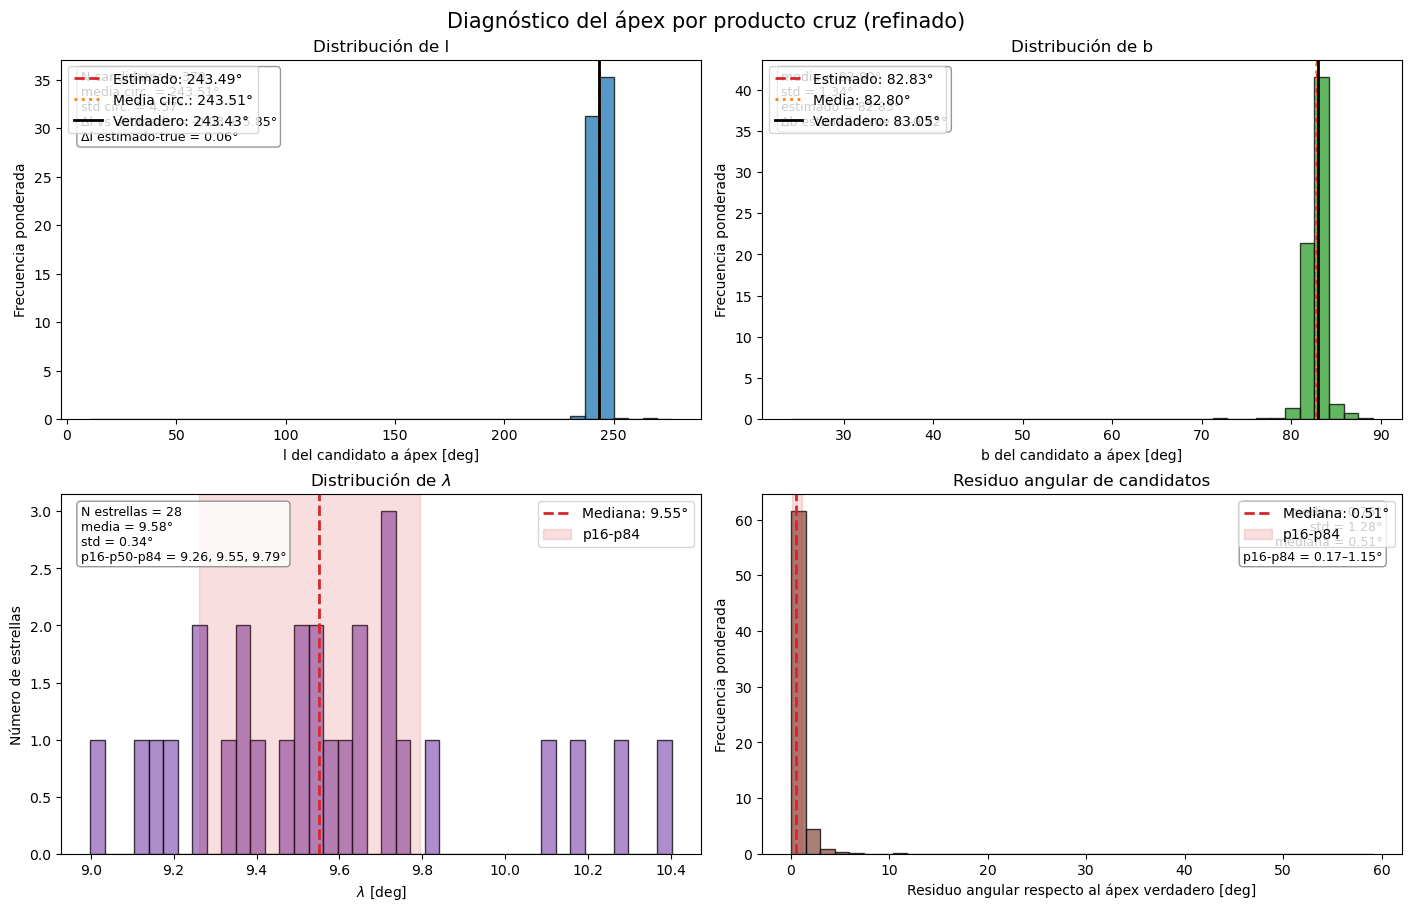

In [20]:
fig, axes, apex_candidates = plot_apex_candidate_diagnostics(
    analysis_result=result,
    true_apex_l_deg=243.43,
    true_apex_b_deg=83.05,
    use_refined=True,
    weight_col=None,
)

plt.show()